# 031 梯度核验与最小调试法
## Goal
把一个训练失败定位到数据、目标、梯度或更新，而不是一开始扩大模型。先用同一组4样本、13参数，逐量追踪完整前向、每一局部导数、链式累计、全部参数梯度、SGD更新和新前向；随后核验同一梯度。再用独立的49参数小网络做单批次、随机标签、矛盾重复和输入扰动诊断。

所有数据人工合成，无训练外验证/测试集；结果不代表泛化或真实性能。先阅读lecture.pdf的完整数值表，再从干净内核顺序执行。

## Setup
在本讲目录打开Notebook；环境见README.md。第一格仅验证教材输入和7份归档结果未被修改，避免旧图与新输入混用。重算在后续格独立执行到notebook_outputs，不从归档读出计算答案。

In [1]:
from pathlib import Path
from make_figures import check_fixed_artifacts
checked = check_fixed_artifacts()
print("固定输入与参考结果已核验：", len(checked), "个文件")

固定输入与参考结果已核验： 9 个文件


In [2]:
import json
import numpy as np
import torch
from IPython.display import display, Image
import experiment as E
torch.set_num_threads(1)
X, y, random_y, cfg = E.load_inputs()
print("CPU", torch.__version__, np.__version__, "float64")
print("X shape", X.shape, "y shape", y.shape)
print(np.column_stack([X, y, random_y]))

CPU 2.7.1+cpu 2.3.5 float64
X shape (8, 2) y shape (8, 1)
[[-1.    -1.    -0.1   -0.975]
 [-1.     0.    -0.5   -0.775]
 [-1.     1.    -0.9   -0.214]
 [ 0.    -1.     0.6    0.368]
 [ 0.     1.    -0.2   -0.723]
 [ 1.    -1.     1.3   -0.775]
 [ 1.     0.     0.9   -0.536]
 [ 1.     1.     0.5    0.515]]


## Steps
### 1. 两样本手算闭环
这里先把原始任务缩成只有w和b的线性例。backward后旧loss仍属于旧参数；更新后必须重新前向。

In [3]:
x2 = torch.tensor([-1., 1.], dtype=torch.float64)
y2 = torch.tensor([-1., 1.], dtype=torch.float64)
wb = torch.tensor([.5, .25], dtype=torch.float64, requires_grad=True)
p2 = x2*wb[0] + wb[1]
l2 = .5*(p2-y2).square().mean()
g2 = torch.autograd.grad(l2, wb)[0]
new_wb = wb.detach() - .1*g2
new_l2 = .5*(x2*new_wb[0]+new_wb[1]-y2).square().mean()
print("预测", p2.detach().tolist(), "残差", (p2-y2).detach().tolist())
print("loss", float(l2.detach()), "gradient", g2.tolist(), "norm", float(g2.norm()))
print("新参数", new_wb.tolist(), "新loss", float(new_l2))

预测 [-0.25, 0.75] 残差 [0.75, -0.25]
loss 0.15625 gradient [-0.5, 0.25] norm 0.5590169943749475
新参数 [0.55, 0.225] 新loss 0.12656249999999997


### 2. 同一13参数例：所有前向坐标
从此格至第7格，始终使用前4条相同样本与同一初始参数，有限差分也不换例子。三列向量顺序为隐藏单元1、2、3。show将shape和全精度数值一起输出。

In [4]:
trace = E.full_trace(X[:4], y[:4], cfg["theta"], eta=.1)
def show(names):
    for name in names:
        print(name, "shape", trace["shapes"][name])
        print(json.dumps(trace["tensors"][name], ensure_ascii=False))
show(["X", "y", "W1", "b1", "W2", "b2", "A", "H", "prediction"])
show(["residual", "per_sample_half_squared_error"])
print("平均loss", trace["loss_before"])

X shape [4, 2]
[[-1.0, -1.0], [-1.0, 0.0], [-1.0, 1.0], [0.0, -1.0]]
y shape [4, 1]
[[-0.1], [-0.5], [-0.9], [0.6]]
W1 shape [2, 3]
[[0.2, -0.3, 0.4], [0.1, 0.25, -0.2]]
b1 shape [3]
[0.05, -0.1, 0.15]
W2 shape [3, 1]
[[0.3], [-0.4], [0.2]]
b2 shape []
-0.05
A shape [4, 3]
[[-0.25000000000000006, -0.05000000000000002, -0.05000000000000002], [-0.15000000000000002, 0.19999999999999998, -0.25], [-0.05, 0.45000000000000007, -0.45000000000000007], [-0.05, -0.35, 0.35]]
H shape [4, 3]
[[-0.2449186624037092, -0.049958374957879984, -0.049958374957879984], [-0.14888503362331798, 0.19737532022490398, -0.24491866240370913], [-0.04995837495787997, 0.42189900525000795, -0.42189900525000795], [-0.04995837495787997, -0.3363755443363322, 0.3363755443363322]]
prediction shape [4, 1]
[[-0.11348392372953676], [-0.2225993706576988], [-0.3181269156373688], [0.13683781411443535]]
residual shape [4, 1]
[[-0.01348392372953676], [0.2774006293423012], [0.5818730843626312], [-0.4631621858855646]]
per_sample_half

### 3. 每段局部导数与上游梯度
L到每个单样本损失的导数是1/4；半平方到残差的导数为residual；残差到预测的导数为1。因此dPrediction=residual/4。输出到隐藏值的局部导数是W2三元素；tanh局部导数是1-H²；将上游乘局部导数得到dH再到dA。不同样本之间的局部导数为0。

In [5]:
show(["dPrediction", "local_tanh_derivative", "dH", "dA"])
print("s0隐藏单元1路径：")
print(trace["tensors"]["dPrediction"][0][0], "*", .3, "*",
      trace["tensors"]["local_tanh_derivative"][0][0], "=", trace["tensors"]["dA"][0][0])

dPrediction shape [4, 1]
[[-0.00337098093238419], [0.0693501573355753], [0.1454682710906578], [-0.11579054647139116]]
local_tanh_derivative shape [4, 3]
[[0.940014848806378, 0.9975041607715679, 0.9975041607715679], [0.9778332467629834, 0.9610429829661166, 0.940014848806378], [0.9975041607715679, 0.8220012293690537, 0.8220012293690537], [0.9975041607715679, 0.8868514931724362, 0.8868514931724362]]
dH shape [4, 3]
[[-0.0010112942797152569, 0.001348392372953676, -0.000674196186476838], [0.02080504720067259, -0.02774006293423012, 0.01387003146711506], [0.04364048132719734, -0.05818730843626312, 0.02909365421813156], [-0.03473716394141735, 0.04631621858855647, -0.023158109294278233]]
dA shape [4, 3]
[[-0.0009506316394452921, 0.0013450270023739397, -0.0006725135011869699], [0.020343866853290798, -0.026659392829980318, 0.013038035532499869], [0.04353156170195326, -0.0478300390682846, 0.0239150195341423], [-0.03465046556496788, 0.04107560761336224, -0.02053780380668112]]
s0隐藏单元1路径：
-0.00337098

### 4. 共享参数的全部路径累计
第一层权重局部导数是相应输入坐标；第一层偏置局部导数为1。末层权重局部导数是隐藏值H；末层偏置为1。parameter_contributions的shape为(4,13)，逐列求和等于每个参数的总梯度，不能再次除以4。

In [6]:
show(["parameter_contributions", "dW1", "db1", "dW2", "db2", "gradient", "dX"])
contributions = np.array(trace["tensors"]["parameter_contributions"])
print("各列累计", contributions.sum(axis=0).tolist())
print("77个坐标逐量核对的最大差", trace["comparison_max_abs"])
for item in trace["comparisons"]:
    print(item["tensor"], item["index"], item["manual"], item["torch"], item["abs_error"])

parameter_contributions shape [4, 13]
[[0.0009506316394452921, -0.0013450270023739397, 0.0006725135011869699, 0.0009506316394452921, -0.0013450270023739397, 0.0006725135011869699, -0.0009506316394452921, 0.0013450270023739397, -0.0006725135011869699, 0.0008256161409479442, 0.00016840872939591323, 0.00016840872939591323, -0.00337098093238419], [-0.020343866853290798, 0.026659392829980318, -0.013038035532499869, 0.0, -0.0, 0.0, 0.020343866853290798, -0.026659392829980318, 0.013038035532499869, -0.01032520050668952, 0.013688009511756648, -0.01698514777211588, 0.0693501573355753], [-0.04353156170195326, 0.0478300390682846, -0.0239150195341423, 0.04353156170195326, -0.0478300390682846, 0.0239150195341423, 0.04353156170195326, -0.0478300390682846, 0.0239150195341423, -0.007267358431621613, 0.06137291886858701, -0.06137291886858701, 0.1454682710906578], [-0.0, 0.0, -0.0, 0.03465046556496788, -0.04107560761336224, 0.02053780380668112, -0.03465046556496788, 0.04107560761336224, -0.0205378038066

### 5. 一次SGD，然后完整的新前向
每个参数减去0.1乘刚才的总梯度。X和y保持不变；A、H必须重算，不能用旧隐藏值。s0单独误差可能变大，而平均目标下降。

In [7]:
show(["theta_before", "gradient", "theta_after"])
show(["A_after", "H_after", "prediction_after", "residual_after"])
print("旧loss", trace["loss_before"], "新loss", trace["loss_after"])

theta_before shape [13]
[0.2, -0.3, 0.4, 0.1, 0.25, -0.2, 0.05, -0.1, 0.15, 0.3, -0.4, 0.2, -0.05]
gradient shape [13]
[-0.06292479691579878, 0.07314440489589097, -0.036280541565455196, 0.07913265890636643, -0.09025067368402079, 0.045125336842010394, 0.028274331350830892, -0.032068797282528726, 0.015742737758774075, -0.010982235260167604, 0.11417844520805516, -0.11713876600962256, 0.09565690102245776]
theta_after shape [13]
[0.20629247969157988, -0.3073144404895891, 0.40362805415654557, 0.09208673410936336, 0.2590250673684021, -0.20451253368420105, 0.047172566864916915, -0.09679312027174714, 0.1484257262241226, 0.30109822352601673, -0.41141784452080554, 0.21171387660096228, -0.05956569010224578]
A_after shape [4, 3]
[[-0.25120664693602635, -0.048503747150560106, -0.050689794248221925], [-0.15911991282666296, 0.21052132021784198, -0.255202327932423], [-0.06703317871729961, 0.469546387586244, -0.45971486161662406], [-0.04491416724444644, -0.3558181876401492, 0.3529382599083236]]
H_after 

### 6. 对同一个初始参数逐坐标差分
差分使用未执行SGD的cfg["theta"]。在float64平滑网络上逐个坐标加减h，独立前向两次。下表列出全部13坐标在h=1e-6的自动梯度、数值梯度和误差。

In [8]:
fd = E.fd_report(X[:4], y[:4], cfg["theta"], cfg["fd_steps"])
for row in fd:
    if row["step"] == 1e-6:
        print(row)
print("各步长最大误差：")
for step in cfg["fd_steps"]:
    print(step, max(r["abs_error"] for r in fd if r["step"] == step))

{'step': 1e-06, 'coordinate': 0, 'autograd': -0.06292479691579876, 'finite_difference': -0.06292479691472064, 'abs_error': 1.0781237014256817e-12, 'tolerance': 6.392479691579876e-07, 'pass': True}
{'step': 1e-06, 'coordinate': 1, 'autograd': 0.07314440489589097, 'finite_difference': 0.07314440489403218, 'abs_error': 1.8587908989786683e-12, 'tolerance': 7.414440489589097e-07, 'pass': True}
{'step': 1e-06, 'coordinate': 2, 'autograd': -0.036280541565455196, 'finite_difference': -0.03628054155713212, 'abs_error': 8.32307833764645e-12, 'tolerance': 3.72805415654552e-07, 'pass': True}
{'step': 1e-06, 'coordinate': 3, 'autograd': 0.07913265890636643, 'finite_difference': 0.07913265890474586, 'abs_error': 1.6205786712575332e-12, 'tolerance': 8.013265890636644e-07, 'pass': True}
{'step': 1e-06, 'coordinate': 4, 'autograd': -0.09025067368402079, 'finite_difference': -0.09025067367746109, 'abs_error': 6.559697229846506e-12, 'tolerance': 9.12506736840208e-07, 'pass': True}
{'step': 1e-06, 'coordi

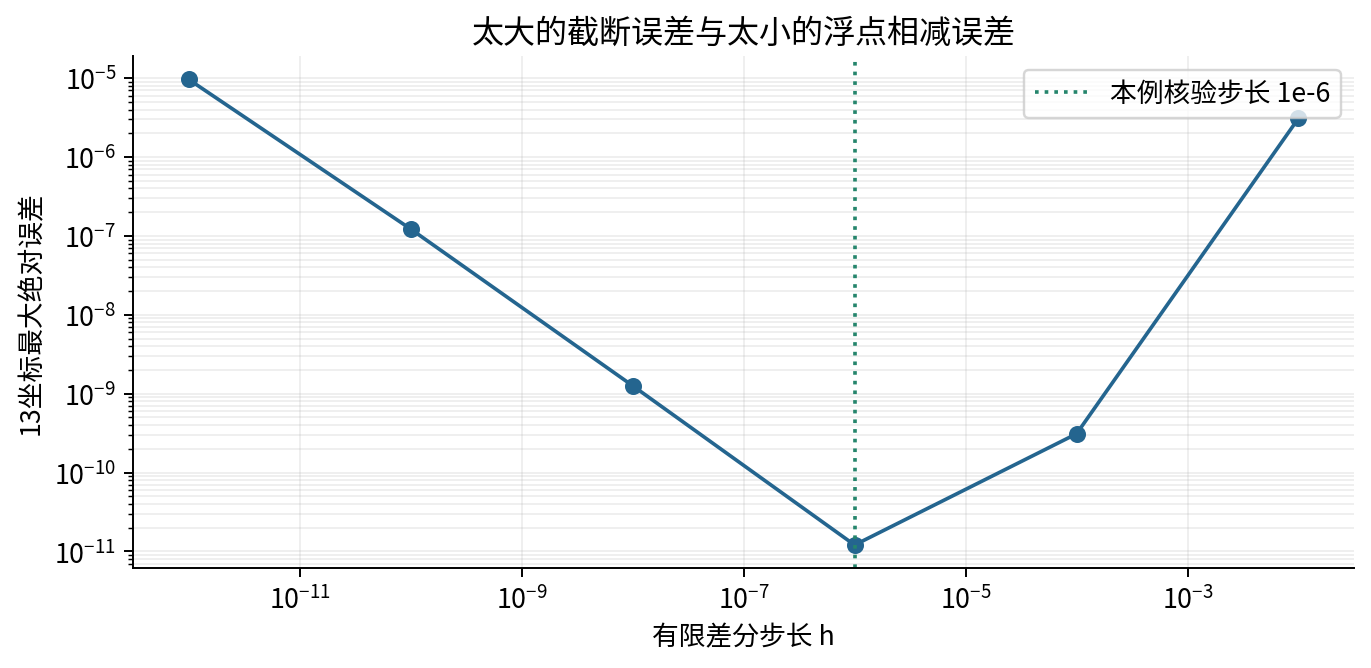

In [9]:
display(Image(filename="figures/03_fd_steps.png"))

### 7. 会失败与会误过关的对照
隐藏层分离会使第一层9坐标失败；标签配错仍能通过导数核验。ReLU在0没有普通导数；单个方向又可能漏掉正交错误。None与数值0分别保留，不能互换。

In [10]:
faults = E.fault_report(X[:4], y[:4], cfg["theta"])
for name in ("gradcheck", "gradient_compare", "none_vs_zero", "relu_at_zero", "direction_blind_spot", "broadcast"):
    print(name, json.dumps(faults[name], ensure_ascii=False))
for mode, probe in faults["one_step"].items():
    print(mode)
    for parameter in probe["parameters"]:
        print(parameter)

gradcheck {"healthy": true, "detached_hidden": false, "permuted_labels": true}
gradient_compare {"loss": 0.07877855276232809, "cut_loss": 0.07877855276232809, "healthy_max_abs": 1.2060651088940944e-11, "cut_max_abs": 0.09025067367746109, "cut_failed_coordinates": [0, 1, 2, 3, 4, 5, 6, 7, 8], "missing_mean_factor_max_abs": 0.35141629802505425}
none_vs_zero {"connected_relu_gradient": 0.0, "unused_gradient_is_none": true}
relu_at_zero {"autograd": 0.0, "central_difference": 0.5, "ordinary_derivative_exists": false}
direction_blind_spot {"true_dot": 2.1213203435596424, "wrong_dot": 2.1213203435596424, "coordinate_error_norm": 1.4142135623730951}
broadcast {"correct_shape": [2, 1], "incorrect_shape": [2, 2], "correct_loss": 0.0, "incorrect_loss": 0.25}
healthy
{'name': 'W1', 'in_optimizer': True, 'grad_is_none': False, 'grad_norm': 0.47057259402887297, 'update_norm': 0.01411717782086618}
{'name': 'b1', 'in_optimizer': True, 'grad_is_none': False, 'grad_norm': 0.2739297302302089, 'update_no

### 8. 独立重算全部诊断
run重新完成13参数trace、差分、故障探针；300步矛盾标签拟合；两次1600步单批次拟合；冻结模型输入扰动。随后比较7份输出的字节。这只验证当前运行栈的可重复结果，不声称跨平台逐字节相同。

In [11]:
summary = E.run(output=Path("notebook_outputs"))
print(json.dumps(summary, ensure_ascii=False, indent=2))
for name in E.OUTPUT_NAMES:
    equal = (Path("outputs")/name).read_bytes() == (Path("notebook_outputs")/name).read_bytes()
    if not equal:
        raise ValueError("固定结果未复现：" + name)
    print(name, "相同")

{
  "torch_version": "2.7.1+cpu",
  "numpy_version": "2.3.5",
  "device": "cpu",
  "dtype": "float64",
  "trace_coordinates": 77,
  "trace_max_abs": 5.551115123125783e-17,
  "trace_loss_after_sgd": 0.07241983164894575,
  "fd_parameter_count": 13,
  "fd_coordinates_times_steps": 78,
  "reference_loss": 0.07877855276232809,
  "torch_loss": 0.07877855276232809,
  "reference_gradient_max_abs": 1.3877787807814457e-17,
  "fd_1e_6_max_abs": 1.2060651088940944e-11,
  "train_parameters": 49,
  "batch_size": 8,
  "updates": 1600,
  "rule_initial_loss": 0.44711795984452135,
  "rule_final_loss": 3.707415142945429e-33,
  "random_initial_loss": 0.2765450395853328,
  "random_final_loss": 1.7559460464294916e-22,
  "scope": "fixed synthetic CPU diagnostics; no validation/test set and no generalization estimate"
}
summary.json 相同
finite-difference.csv 相同
training.csv 相同
faults.json 相同
perturbations.json 相同
fitted-values.csv 相同
full-trace.json 相同


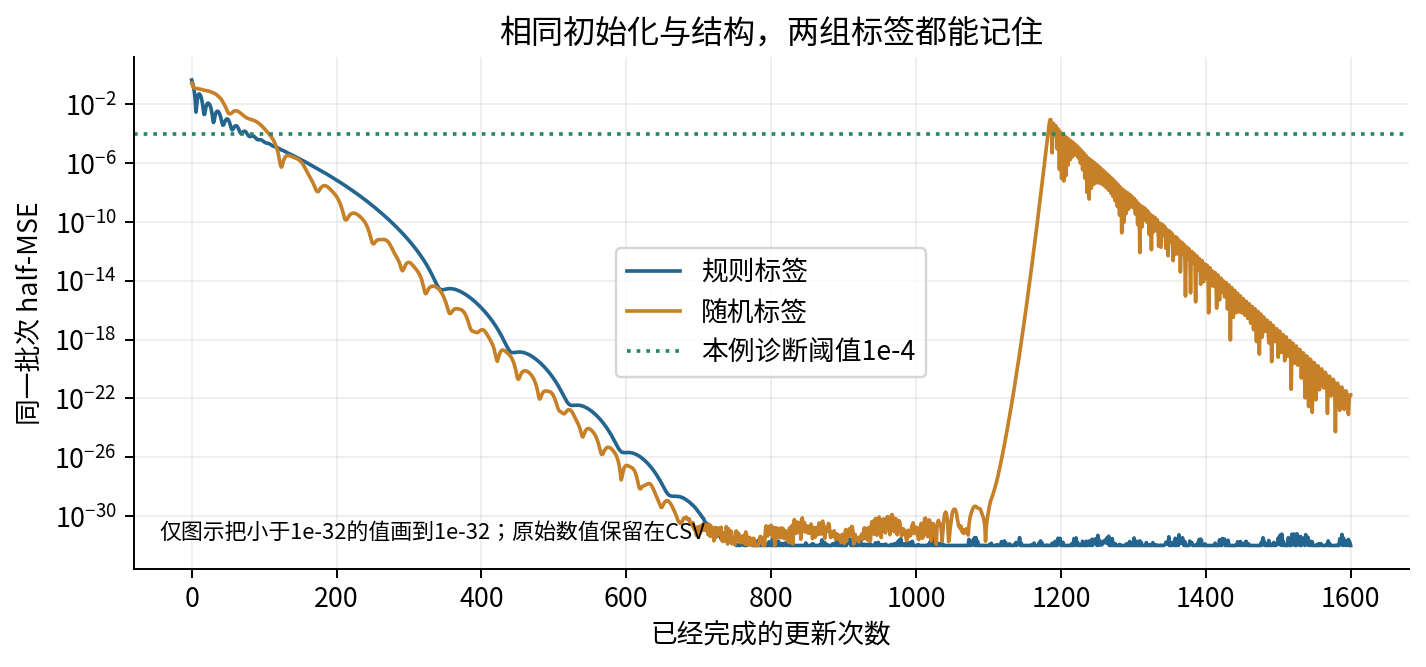

矛盾重复标签 {'same_input': [0.0, 0.0], 'targets': [-1.0, 1.0], 'optimal_prediction': 0.0, 'minimum_half_mse': 0.5, 'actual_final_half_mse': 0.49999999999999994}


In [12]:
display(Image(filename="figures/06_batch_fits.png"))
recomputed_faults = json.loads(Path("notebook_outputs/faults.json").read_text())
print("矛盾重复标签", recomputed_faults["contradictory_duplicate"])

### 9. 输入干预与机制反例
以下数值由刚才重算产生。原训练点几乎零误差，而x1的小扰动平均变化率仍约0.584，与规则0.7不同。缩小epsilon会使绝对loss下降，不会自动修复斜率。

{
  "fixed_model": true,
  "baseline_loss": 3.707415142945429e-33,
  "joint_row_permutation_loss": 3.707415142945429e-33,
  "input_only_permutation_loss": 0.9750000000000001,
  "zero_input_loss_original_targets": 0.24375600778741263,
  "mean_target_constant_loss": 0.24375000000000002,
  "small_shifts": [
    {
      "epsilon": 0.1,
      "mean_abs_prediction_change": 0.058413848185920415,
      "mean_slope": 0.5841384818592041,
      "known_rule_slope": 0.7,
      "loss_against_shifted_rule": 0.00016049639417565727
    },
    {
      "epsilon": 0.01,
      "mean_abs_prediction_change": 0.0058387052753481605,
      "mean_slope": 0.583870527534816,
      "known_rule_slope": 0.7,
      "loss_against_shifted_rule": 1.617335178290586e-06
    },
    {
      "epsilon": 0.001,
      "mean_abs_prediction_change": 0.0005838273540142783,
      "mean_slope": 0.5838273540142782,
      "known_rule_slope": 0.7,
      "loss_against_shifted_rule": 1.6193661670044126e-08
    }
  ],
  "scope": "synthetic

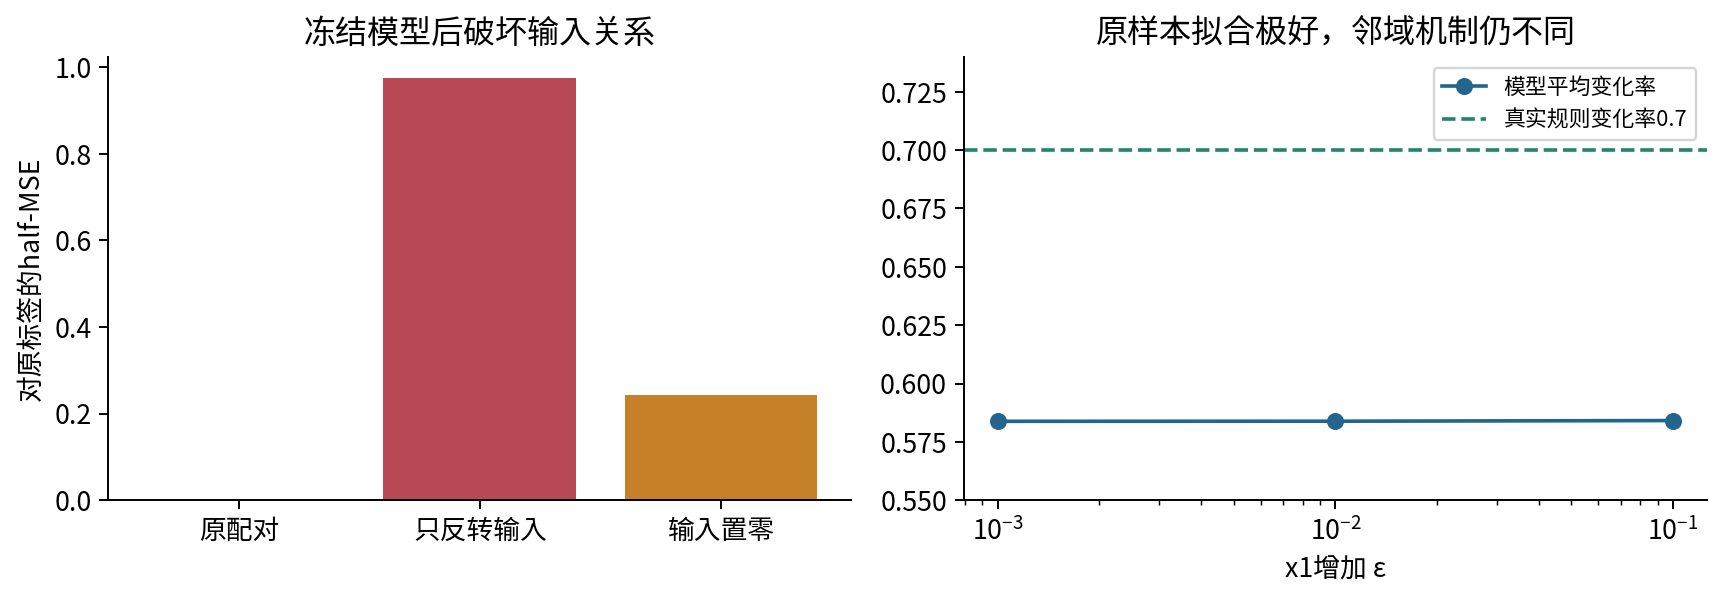

In [13]:
perturb = json.loads(Path("notebook_outputs/perturbations.json").read_text())
print(json.dumps(perturb, ensure_ascii=False, indent=2))
display(Image(filename="figures/08_input_interventions.png"))

## Checks
同一套13参数的77个中间值/梯度坐标与独立计算一致；13坐标中央差分在h=1e-6通过；完整故障对照产生预期差异；两种标签均能被同一49参数结构拟合；矛盾重复数据的下界为0.5；7份输出与参考字节一致。

这些是固定CPU合成诊断。既没有估计未见数据的误差，也没有验证GPU、浏览器Jupyter界面或跨版本逐字节复现。

## Next Steps
按lab.pdf提交可定位报告：选择omit_W1或detach_hidden，记录预期、最小复现、参数身份、梯度与更新、单变量修复及回归断言。完整答案在answers.pdf。完成最小排查后逐项恢复真实训练复杂性，再另行设计独立统计评价。